In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Model imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns',200)
%matplotlib inline

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
#Loading the data
path="data/For_modeling.csv.zip"

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
data = pd.read_csv(path, 
                  dtype={
                      'Duration': 'int8',
                      'Distance': 'int8',
                      'PLong': 'float32',
                      'PLatd': 'float32',
                      'DLong': 'float32',
                      'Haversine':'float32',
                      'Pmonth':'int8',
                      'Pday':'int8',
                      'Phour':'int8',
                      'Pmin':'int8',
                      'PDweek':'int8',
                      'Dmonth':'int8',
                      'Dday':'int8',
                      'Dhour':'int8',
                      'Dmin':'int8',
                      'DDweek':'int8',
                      'Temp':'float32',
                      'Precip':'float32',
                      'Wind':'float32',
                      'Solar':'float32',
                      'Snow':'float32',
                      'GroundTemp':'float32',
                      'Dust':'float32'
                  },index_col=0
                  
                  ).sample(frac=1)

#checking for data
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
9782843,5,-110,37.557968,126.838287,37.560242,126.827164,1.012541,12,27,3,7,3,12,27,3,13,3,-9.400000,0.0,2.5,28.0,0.00,0.0,-5.800000,23.0
2824745,12,78,37.537308,127.070351,37.553417,127.073196,1.808718,6,12,11,31,1,6,12,11,44,1,22.900000,0.0,2.6,54.0,2.56,0.0,30.799999,15.0
6524381,16,-84,37.509720,126.890099,37.495781,126.890121,1.549949,9,21,15,8,4,9,21,15,24,4,21.799999,0.0,1.4,76.0,1.20,0.0,25.500000,7.0
3334397,4,-26,37.608978,127.020248,37.607105,127.021500,0.235667,6,25,6,39,0,6,25,6,44,0,21.299999,0.0,0.7,81.0,0.05,0.0,20.600000,28.0
9641191,65,0,37.619305,126.920593,37.610779,126.917351,0.990122,12,19,2,8,2,12,19,3,17,2,3.100000,0.0,1.1,74.0,0.00,0.0,-0.900000,43.0
4704890,13,110,37.615299,127.064468,37.622662,127.061897,0.849467,8,4,23,19,5,8,4,23,32,5,28.200001,0.0,2.5,78.0,0.00,0.0,27.500000,21.0
4153385,12,-48,37.548222,127.067879,37.544590,127.057083,1.033936,7,19,8,44,3,7,19,8,56,3,25.500000,0.0,0.9,65.0,1.10,0.0,27.799999,23.0
5786733,15,-98,37.577469,126.897362,37.584381,126.909897,1.345681,9,5,19,30,2,9,5,19,46,2,25.400000,0.0,3.2,55.0,0.15,0.0,24.000000,22.0
3556889,25,-84,37.571476,126.889687,37.568420,126.899429,0.923403,7,3,20,33,1,7,3,20,59,1,28.799999,0.0,0.9,72.0,0.11,0.0,26.100000,6.0
9208344,29,-108,37.506367,127.034523,37.511517,127.021477,1.285355,11,26,13,52,0,11,26,14,22,0,11.700000,0.0,1.4,50.0,1.74,0.0,16.600000,66.0


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
#Resetting index
data = data.reset_index().drop(columns=['index'])
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
0,5,-110,37.557968,126.838287,37.560242,126.827164,1.012541,12,27,3,7,3,12,27,3,13,3,-9.400000,0.0,2.5,28.0,0.00,0.0,-5.800000,23.0
1,12,78,37.537308,127.070351,37.553417,127.073196,1.808718,6,12,11,31,1,6,12,11,44,1,22.900000,0.0,2.6,54.0,2.56,0.0,30.799999,15.0
2,16,-84,37.509720,126.890099,37.495781,126.890121,1.549949,9,21,15,8,4,9,21,15,24,4,21.799999,0.0,1.4,76.0,1.20,0.0,25.500000,7.0
3,4,-26,37.608978,127.020248,37.607105,127.021500,0.235667,6,25,6,39,0,6,25,6,44,0,21.299999,0.0,0.7,81.0,0.05,0.0,20.600000,28.0
4,65,0,37.619305,126.920593,37.610779,126.917351,0.990122,12,19,2,8,2,12,19,3,17,2,3.100000,0.0,1.1,74.0,0.00,0.0,-0.900000,43.0
5,13,110,37.615299,127.064468,37.622662,127.061897,0.849467,8,4,23,19,5,8,4,23,32,5,28.200001,0.0,2.5,78.0,0.00,0.0,27.500000,21.0
6,12,-48,37.548222,127.067879,37.544590,127.057083,1.033936,7,19,8,44,3,7,19,8,56,3,25.500000,0.0,0.9,65.0,1.10,0.0,27.799999,23.0
7,15,-98,37.577469,126.897362,37.584381,126.909897,1.345681,9,5,19,30,2,9,5,19,46,2,25.400000,0.0,3.2,55.0,0.15,0.0,24.000000,22.0
8,25,-84,37.571476,126.889687,37.568420,126.899429,0.923403,7,3,20,33,1,7,3,20,59,1,28.799999,0.0,0.9,72.0,0.11,0.0,26.100000,6.0
9,29,-108,37.506367,127.034523,37.511517,127.021477,1.285355,11,26,13,52,0,11,26,14,22,0,11.700000,0.0,1.4,50.0,1.74,0.0,16.600000,66.0


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#Dropping value with haversine ==0
data= data[data['Haversine']!=0].reset_index().drop(columns=['index'])
#data.shape

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
#transforming all the negative distance to posiive distances

data["Distance"]=data['Distance'].apply(lambda x:abs(x))
data[data['Distance']<0].shape

(0, 25)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
#Dropping values with diatance is zero, that indicate trip was never occured or error in recordings or something
data = data[data['Distance']!=0].reset_index().drop(columns=['index'])
data[data['Distance']==0].shape

(0, 25)

<ipython-input-8-130938f4d694>:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_duration = data.groupby('DayOfWeek')['Duration'].mean()


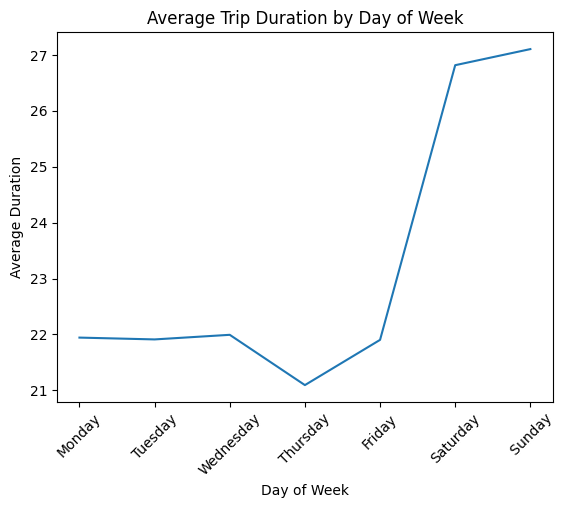

In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# === BEFORE (original) ===
# #Average Trip Duration by Day of Week
# # Convert the 'PDweek' column to a day of the week name
# data1= pd.Categorical(data['PDweek'], categories=range(7), ordered=True)
# data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], inplace=True)
# 
# # Calculate the average trip duration for each day of the week
# average_duration = data1.groupby('DayOfWeek')['Duration'].mean()
# 
# # Create a line chart
# plt.plot(average_duration.index, average_duration.values)
# plt.xlabel('Day of Week')
# plt.ylabel('Average Duration')
# plt.title('Average Trip Duration by Day of Week')
# plt.xticks(rotation=45)
# plt.show()

# === AFTER (edited) ===
data['PDweek'] = pd.Categorical(data['PDweek'], categories=range(7), ordered=True)
data['PDweek'] = data['PDweek'].cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', ' Sunday'])

data = data.rename(columns={'PDweek': 'DayOfWeek'})

average_duration = data.groupby('DayOfWeek')['Duration'].mean()

plt.plot(average_duration.index, average_duration.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Duration')
plt.title('Average Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Behavioral test for day-of-week aggregation fix
expected_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
assert 'DayOfWeek' in data.columns, 'Expected DayOfWeek column to be created on data'
assert str(data['DayOfWeek'].dtype) == 'category', 'DayOfWeek should be categorical'
assert list(data['DayOfWeek'].cat.categories) == expected_days, 'DayOfWeek categories should be renamed to weekday names'
assert average_duration.index.name == 'DayOfWeek', 'Aggregation should group by DayOfWeek on data'
assert len(average_duration) == 7, 'Expected one aggregated value per weekday'

AssertionError: DayOfWeek categories should be renamed to weekday names